# Лабораторная работа 1. Анализ Big Data-сценария по 5V: NYC Yellow Taxi

## Введение

**Датасет:** [NYC Yellow Taxi Trip Data](https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data). Поездки жёлтого такси Нью-Йорка, выгрузка NYC TLC: 4 месяца (2015-01, 2016-01...03), \~47 млн записей, 7.4 ГБ CSV. Каждая запись - одна поездка: время посадки и высадки, GPS-координаты, дистанция, тариф и состав оплаты.

**Бизнес-сценарий:** №3 "Прогнозирование спроса".

| | Формулировка задания | Интерпретация для такси |
|---|---|---|
| Заказчик | | Оператор таксопарка / диспетчерская служба |
| Цель | Сократить избыток запасов на 25 % | "Запас" таксопарка - машино-часы на линии. Избыток - машины без пассажира (холостой пробег, простой). Цель: **-25 % холостых машино-часов** за счёт почасового прогноза спроса по районам и планирования смен |
| Ограничение | Ежедневный прогноз готов до 06:00 | Прогноз спроса на следующие сутки в разрезе *гео-ячейка X час* формируется ночным пакетом к 6:00, до утреннего пика |
| Особенности | Внешние факторы | Погода, праздники, городские события, сезонность |

**Цели анализа:**
1. Оценить данные по 5V и понять, какие из V критичны именно для прогноза спроса.
2. Выбрать технологии под измеренные (а не предполагаемые) характеристики данных.
3. Оценить экономику решения: стоимость хранения и обработки, ROI.

**Структура:** 0 - подготовка; 1 - Volume; 2 - Velocity; 3 - Variety; 4 - Veracity; 5 - Value; 6 - Технологии; Заключение.

## 0. Подготовка окружения

```bash
uv sync    # создаст .venv со всеми зависимостями
```

В PyCharm / Jupyter выберите интерпретатор `.venv`. Ноутбук сам скачивает данные через `kagglehub` в `data/` (каталог в `.gitignore`). Первый запуск качает \~1.8 ГБ архива и конвертирует CSV в Parquet, это занимает несколько минут. Повторные запуски берут файлы из кэша.

**Инструмент обработки - Polars.** 47 млн строк в pandas занимают \~9 ГБ RAM (замер в п. 1.1), а промежуточные копии при join/groupby требуют ещё столько же - на ноутбуке с 16 ГБ это за пределом. Polars в lazy-режиме читает CSV/Parquet потоково (out-of-core), использует все ядра и при этом не требует JVM и кластера (как Spark). Pandas используется только для замера памяти.

In [2]:
import os
import shutil
import time
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
os.environ.setdefault("KAGGLEHUB_CACHE", str(DATA_DIR / "kagglehub"))  # kagglehub читает путь при импорте

warnings.filterwarnings("ignore", message="IProgress not found")  # прогресс-бар kagglehub без ipywidgets
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

warnings.filterwarnings("ignore", category=pl.exceptions.UnstableWarning)  # write_avro помечен как unstable
sns.set_theme(style="whitegrid", palette=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"],
              rc={"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_float_precision(2)
pl.Config.set_thousands_separator(" ");

### 0.1. Загрузка данных

Заголовки файлов 2015 и 2016 годов различаются (`RateCodeID` / `RatecodeID`), поэтому задаём **явную схему** с едиными именами и типами, а не полагаемся на автоопределение. Подробнее о разнообразии форматов в части 3.

In [3]:
RAW_DIR = Path(kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data"))  # повторно берётся из кэша
CSV_FILES = sorted(RAW_DIR.glob("*.csv"))
for f in CSV_FILES:
    print(f.name, f.open().readline().split(",")[7])

# Порядок колонок во всех файлах одинаков, отличаются только имена
SCHEMA = {
    "vendor_id": pl.Int8, "pickup_datetime": pl.Datetime, "dropoff_datetime": pl.Datetime,
    "passenger_count": pl.Int8, "trip_distance": pl.Float64,
    "pickup_longitude": pl.Float64, "pickup_latitude": pl.Float64, "rate_code_id": pl.Int8,
    "store_and_fwd_flag": pl.String, "dropoff_longitude": pl.Float64, "dropoff_latitude": pl.Float64,
    "payment_type": pl.Int8, "fare_amount": pl.Float64, "extra": pl.Float64, "mta_tax": pl.Float64,
    "tip_amount": pl.Float64, "tolls_amount": pl.Float64, "improvement_surcharge": pl.Float64,
    "total_amount": pl.Float64,
}


def scan_csv(path: Path) -> pl.LazyFrame:
    """Ленивое чтение CSV в единой схеме + month - месяц выгрузки из имени файла."""
    return (pl.scan_csv(path, with_column_names=lambda _: list(SCHEMA), schema_overrides=SCHEMA)
            .with_columns(month=pl.lit(path.stem[-7:])))

yellow_tripdata_2015-01.csv RateCodeID
yellow_tripdata_2016-01.csv RatecodeID
yellow_tripdata_2016-02.csv RatecodeID
yellow_tripdata_2016-03.csv RatecodeID


## Часть 1. Анализ Volume

### 1.1. Текущий объём данных

Объём в несжатом виде - размер CSV на диске.

In [4]:
volume = pl.DataFrame([
    {"file": f.name, "csv_gb": f.stat().st_size / 1e9, "rows_mln": scan_csv(f).select(pl.len()).collect().item() / 1e6}
    for f in CSV_FILES
])
volume = pl.concat([volume, volume.sum().with_columns(file=pl.lit("Итого"))])
display(volume.with_columns(bytes_per_row=pl.col("csv_gb") / pl.col("rows_mln") * 1e3))

file,csv_gb,rows_mln,bytes_per_row
str,f64,f64,f64
"""yellow_tripdata_2015-01.csv""",1.99,12.75,155.77
"""yellow_tripdata_2016-01.csv""",1.71,10.91,156.66
"""yellow_tripdata_2016-02.csv""",1.78,11.38,156.70
"""yellow_tripdata_2016-03.csv""",1.91,12.21,156.80
"""Итого""",7.39,47.25,156.47


### 1.2. Сравнение форматов хранения

Эталонный месяц сохраняем в Parquet и Avro и для каждого варианта замеряем размер, время записи и время типового запроса "поездки по часам" (читает 1 колонку из 19).

In [5]:
ref = CSV_FILES[1]  # 2016-01 - эталонный месяц для замеров
ref_df = scan_csv(ref).drop("month").collect()
tmp = DATA_DIR / "bench"
tmp.mkdir(exist_ok=True)
avro_df = ref_df.with_columns(pl.col(pl.Int8).cast(pl.Int32))  # в Avro нет 8-битных целых


def bench(fmt: str, path: Path, codec: str = "uncompressed") -> dict:
    t0 = time.perf_counter()
    if path.suffix == ".parquet":
        ref_df.write_parquet(path, compression=codec)
    elif path.suffix == ".avro":
        avro_df.write_avro(path, compression=codec)
    t1 = time.perf_counter()  # исходный CSV не перезаписываем, write_s = 0

    if path.suffix == ".parquet":
        lf = pl.scan_parquet(path)
    elif path.suffix == ".avro":
        lf = pl.read_avro(path).lazy()  # Avro - строчный формат: одну колонку не прочитать, читаем всё
    else:
        lf = scan_csv(path)
    lf.group_by(pl.col("pickup_datetime").dt.truncate("1h")).len().collect()
    t2 = time.perf_counter()
    return {"format": fmt, "size_mb": path.stat().st_size / 1e6, "write_s": t1 - t0, "query_s": t2 - t1}


formats = pl.DataFrame([
    bench("CSV", ref),
    bench("Parquet snappy", tmp / "snappy.parquet", "snappy"),
    bench("Parquet zstd", tmp / "zstd.parquet", "zstd"),
    bench("Avro", tmp / "plain.avro"),
    bench("Avro deflate", tmp / "deflate.avro", "deflate"),
])
shutil.rmtree(tmp)

# Во сколько раз формат меньше и быстрее CSV
formats.with_columns(compression_x=pl.first("size_mb") / pl.col("size_mb"),
                     query_speedup_x=pl.first("query_s") / pl.col("query_s"))

format,size_mb,write_s,query_s,compression_x,query_speedup_x
str,f64,f64,f64,f64,f64
"""CSV""",1 708.67,0.00,1.35,1.00,1.00
"""Parquet snappy""",403.25,0.32,0.02,4.24,77.24
"""Parquet zstd""",246.77,0.50,0.02,6.92,82.17
"""Avro""",1 494.31,1.37,2.78,1.14,0.49
"""Avro deflate""",476.39,20.42,6.59,3.59,0.21


Рабочий формат - Parquet + zstd. Конвертируем в него весь датасет, дальше все части работают с этой копией.

In [6]:
PARQUET_DIR = DATA_DIR / "parquet"
PARQUET_DIR.mkdir(exist_ok=True)
for f in CSV_FILES:
    if not (PARQUET_DIR / f"{f.stem}.parquet").exists():  # при повторном запуске пропускаем
        scan_csv(f).sink_parquet(PARQUET_DIR / f"{f.stem}.parquet", compression="zstd")

trips = pl.scan_parquet(PARQUET_DIR / "*.parquet")
csv_gb, rows = volume.row(-1)[1], volume.row(-1)[2] * 1e6
parquet_gb = sum(p.stat().st_size for p in PARQUET_DIR.glob("*.parquet")) / 1e9
print(f"CSV {csv_gb:.2f} ГБ -> Parquet {parquet_gb:.2f} ГБ (x{csv_gb / parquet_gb:.2f})")

CSV 7.39 ГБ -> Parquet 1.09 ГБ (x6.78)


### 1.3. Прогноз роста объёма

Прирост считаем по датам посадки. Поездки с датой вне месяца выгрузки отбрасываем (это ошибки, разберём в части 4). Сценарий C - подключение GPS-телеметрии парка: поездки показывают только удовлетворённый спрос, а холостые машино-часы видны лишь по трекам свободных машин. Допущения для C: парк - 13 587 машин. Это максимум жёлтых такси в Нью-Йорке: для работы нужен медальон (лицензия комиссии по такси NYC TLC), а их число ограничено законом. Каждая машина отправляет GPS-точку раз в 10 с, 16 ч в сутки на линии, \~20 байт на точку в Parquet.

387,286 поездок/день; январь 2016 к январю 2015: -15%


scenario,mb_per_day,gb_per_year,months_to_1tb
str,f64,f64,f64
"""A. Поездки, Parquet""",8.94,3.26,3 679.31
"""B. Поездки, CSV""",60.60,22.12,542.84
"""C. Поездки + GPS-телеметрия""",1 574.16,574.57,20.90


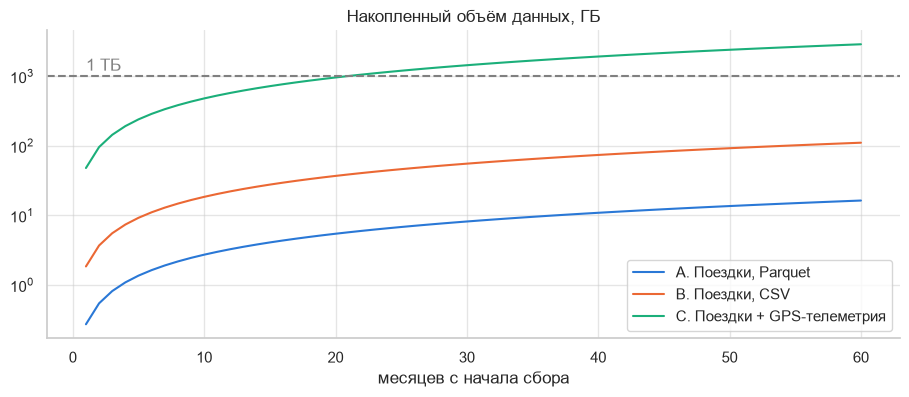

In [7]:
daily = (
    trips.filter(pl.col("pickup_datetime").dt.strftime("%Y-%m") == pl.col("month"))
    .group_by("month", day=pl.col("pickup_datetime").dt.date()).len()
    .sort("day").collect()
)
trips_per_day = daily["len"].mean()
jan = dict(daily.group_by("month").agg(pl.median("len")).iter_rows())  # медиана: в январях были метели
print(f"{trips_per_day:,.0f} поездок/день; январь 2016 к январю 2015: {jan['2016-01'] / jan['2015-01'] - 1:+.0%}")

gb_per_day = {
    "A. Поездки, Parquet": trips_per_day * parquet_gb / rows,
    "B. Поездки, CSV": trips_per_day * csv_gb / rows,
    "C. Поездки + GPS-телеметрия": trips_per_day * parquet_gb / rows + 13_587 * 16 * 3600 / 10 * 20 / 1e9,
}
display(pl.DataFrame({"scenario": gb_per_day.keys(), "gb_per_day": gb_per_day.values()}).select(
    "scenario", mb_per_day=pl.col("gb_per_day") * 1e3, gb_per_year=pl.col("gb_per_day") * 365,
    months_to_1tb=1000 / (pl.col("gb_per_day") * 30.4)))

months = range(1, 61)
for name, gb in gb_per_day.items():
    plt.plot(months, [gb * 30.4 * m for m in months], label=name)
plt.axhline(1000, ls="--", c="gray")
plt.text(1, 1200, "1 ТБ", c="gray")
plt.yscale("log")
plt.title("Накопленный объём данных, ГБ")
plt.xlabel("месяцев с начала сбора")
plt.legend()
plt.show()

### 1.4. Горячие и архивные данные

Модель прогноза работает не с поездками, а с агрегатом **гео-ячейка X час** (число посадок), из него же берутся лаги и сезонность. Оценим его размер: ячейка \~1 X 1 км в границах Нью-Йорка.

In [8]:
cells = (
    trips.filter(pl.col("pickup_latitude").is_between(40.49, 40.92) & pl.col("pickup_longitude").is_between(-74.27, -73.68))
    .group_by(hour=pl.col("pickup_datetime").dt.truncate("1h"),
              cell_lat=(pl.col("pickup_latitude") / 0.01).floor().cast(pl.Int32),
              cell_lon=(pl.col("pickup_longitude") / 0.012).floor().cast(pl.Int32))
    .len().collect()
)
cells.write_parquet(DATA_DIR / "demand_cell_hour.parquet")
agg_mb = (DATA_DIR / "demand_cell_hour.parquet").stat().st_size / 1e6
print(f"Агрегат: {cells.height:,} строк, {agg_mb:.1f} МБ - в {parquet_gb * 1e3 / agg_mb:.0f} раз меньше поездок в Parquet")

Агрегат: 477,434 строк, 1.6 МБ - в 703 раз меньше поездок в Parquet


Отсюда политика хранения:

| Слой | Данные | Класс Object Storage |
|---|---|---|
| Горячий | Агрегат ячейка X час за всю историю, сырые поездки за 3 месяца | STANDARD |
| Тёплый | Сырые поездки 3-24 месяца (переобучение с годовой сезонностью) | COLD |
| Архив | Сырые поездки старше 2 лет, исходные CSV | ICE |

### 1.5. Стоимость хранения в Yandex Object Storage

По [тарифам](https://yandex.cloud/ru/docs/storage/pricing) (10.2026, с НДС): STANDARD 2.38 ₽, COLD 1.27 ₽, ICE 0.63 ₽ за ГБ в месяц, первый 1 ГБ бесплатно. Операции GET/PUT в пакетном сценарии стоят копейки (0.46 ₽ за 10 000 GET), их тут не учитываем.

- **Поездки, Parquet (3.3 ГБ/год).** Платим каждый месяц за то, что лежит в хранилище, а данные копятся постепенно: в 1-м месяце лежит 0.27 ГБ, во 2-м 0.54 ГБ, ..., в 12-м 3.3 ГБ. Первые 3 месяца укладываются в бесплатный 1 ГБ, платные объёмы за месяцы 4-12 в сумме дают \~10.5 ГБ: 10.5 X 2.38 = **\~25 ₽ за первый год**. Когда в хранилище постоянно лежит год данных: (3.3 - 1) X 2.38 X 12 = **\~65 ₽/год**.
- **Сценарий C (575 ГБ/год).** Каждый месяц добавляется \~48 ГБ, сумма объёмов за 12 месяцев: 48 X (1 + 2 + ... + 12) = \~3 700 ГБ. В STANDARD: 3 700 X 2.38 = **\~8.9 тыс. ₽** за первый год, с переносом данных старше 3 месяцев в COLD **\~6.5 тыс. ₽** (-27 %). Когда постоянно лежит год данных: 575 X 2.38 X 12 = \~16 тыс. ₽/год.

### 1.6. Когда переходить от pandas к Spark

Pandas держит месяц (10.9 млн поездок) в 2.1 ГБ RAM, это больше самого CSV. С двукратным запасом на копии при join/groupby на 16 ГБ помещается \~40 млн поездок, то есть \~3.5 месяца данных, а для годовой сезонности нужен минимум год. Polars в lazy-режиме обрабатывает данные потоково и на одном узле справляется с объёмом до \~1 ТБ. Spark нужен после \~1 ТБ, либо если ночной пересчёт перестанет укладываться в окно до 06:00.

### Выводы по Volume

- 7.4 ГБ CSV, 47 млн поездок. Parquet + zstd сжимает в **x7** и ускоряет запрос по одной колонке **в десятки раз**.
- Прирост \~9 МБ/день, \~3.3 ГБ/год в Parquet. По поездкам 1 ТБ не наберётся никогда: \~300 лет при текущем потоке, а поток к тому же падает на 15 % в год. С GPS-телеметрией 1 ТБ наберётся за \~21 месяц.
- Модели нужен агрегат ячейка X час, он в \~700 раз меньше сырых поездок. Горячими держим его и последние 3 месяца поездок, остальное переносим в COLD/ICE.
- Хранение стоит десятки рублей в год. **Volume для этого сценария не критичен**: стоимость проекта определяют разработка и вычисления. Поездки обрабатываются Polars на одной машине, Spark понадобится только с телеметрией.

## Часть 2. Анализ Velocity

### 2.1. Частота поступления данных

Поток считаем по времени посадки в 5-минутных окнах. Коэффициент вариации (CV = std / mean) показывает стабильность потока: чем он больше, тем сильнее пики отличаются от среднего.

Среднее: 4 записей/с, пик за 5 мин: 10 записей/с (x2.1), CV = 0.48


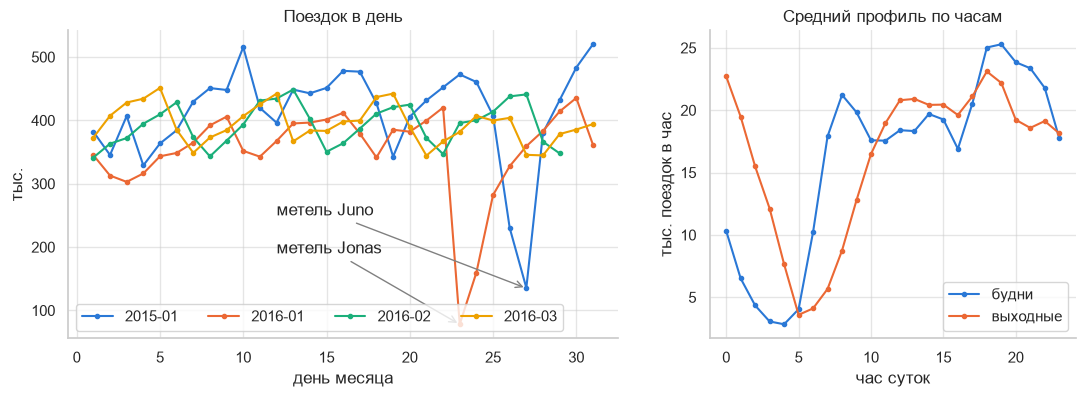

In [9]:
per_5min = (
    trips.filter(pl.col("pickup_datetime").dt.strftime("%Y-%m") == pl.col("month"))
    .group_by(pl.col("pickup_datetime").dt.truncate("5m")).len().collect()
)
avg_rps = per_5min["len"].mean() / 300
peak_rps = per_5min["len"].max() / 300
cv = per_5min["len"].std() / per_5min["len"].mean()
print(f"Среднее: {avg_rps:.0f} записей/с, пик за 5 мин: {peak_rps:.0f} записей/с (x{peak_rps / avg_rps:.1f}), CV = {cv:.2f}")

hourly = (
    trips.group_by(weekend=pl.col("pickup_datetime").dt.weekday() >= 6, hour=pl.col("pickup_datetime").dt.hour())
    .len().collect()
    .with_columns(per_hour=pl.col("len") / pl.when(pl.col("weekend")).then(daily.height * 2 / 7).otherwise(daily.height * 5 / 7))
    .sort("hour")
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [3, 2]})
for month, part in daily.group_by("month", maintain_order=True):
    ax1.plot(part["day"].dt.day(), part["len"] / 1e3, marker="o", markersize=3, label=month[0])
ax1.annotate("метель Jonas", (23, 78), xytext=(12, 190), arrowprops={"arrowstyle": "->", "color": "gray"})
ax1.annotate("метель Juno", (27, 135), xytext=(12, 250), arrowprops={"arrowstyle": "->", "color": "gray"})
ax1.set(title="Поездок в день", xlabel="день месяца", ylabel="тыс.")
ax1.legend(ncols=4, loc="lower left")
for weekend, part in hourly.group_by("weekend", maintain_order=True):
    ax2.plot(part["hour"], part["per_hour"] / 1e3, marker="o", markersize=3, label="выходные" if weekend[0] else "будни")
ax2.set(title="Средний профиль по часам", xlabel="час суток", ylabel="тыс. поездок в час")
ax2.legend()
plt.show()

### 2.2. Задержка при разных режимах обработки и потери при сбое

Задержка - время от события до того, как оно попало в результат. При пакетной обработке раз в N минут событие в среднем ждёт N/2, в худшем случае N, плюс время обработки. При сбое на 30 минут в систему не попадёт всё, что пришло за эти 30 минут, если перед обработкой нет буфера (например, Kafka с хранением сообщений).

In [10]:
pl.DataFrame({
    "mode": ["batch раз в час", "micro-batch 5 мин", "streaming"],
    "avg_latency_s": [1800, 150, 1],
    "max_latency_s": [3600, 300, 5],
}).with_columns(
    lost_30min_avg=pl.lit(int(avg_rps * 1800)),
    lost_30min_peak=pl.lit(int(peak_rps * 1800)),
)

mode,avg_latency_s,max_latency_s,lost_30min_avg,lost_30min_peak
str,i64,i64,i32,i32
"""batch раз в час""",1 800,3 600,8 080,17 148
"""micro-batch 5 мин""",150,300,8 080,17 148
"""streaming""",1,5,8 080,17 148


### 2.3. Допустимая задержка и ресурсы

Прогноз на сутки D+1 нужен к 06:00 суток D+1, а последние поездки суток D приходят в 24:00. Значит, весь ночной пакет (загрузка, проверка качества, пересчёт признаков, обучение, прогноз) должен уложиться в **6 часов = 21 600 с**. Свежесть данных, превышающая сутки, прогнозу не нужна: у почасового спроса сильная недельная сезонность, а не минутная динамика.

Ресурсы оцениваем по замеру: сколько строк в секунду Polars агрегирует до ячейка X час на этой машине (10 ядер Apple M4).

In [11]:
t0 = time.perf_counter()
trips.group_by(pl.col("pickup_datetime").dt.truncate("1h"),
               (pl.col("pickup_latitude") / 0.01).floor(), (pl.col("pickup_longitude") / 0.012).floor()).len().collect()
throughput = rows / (time.perf_counter() - t0)

peak_day = daily["len"].max()
telemetry_day = 13_587 * 16 * 3600 / 10
print(f"Пропускная способность: {throughput / 1e6:.0f} млн строк/с")
print(f"Пиковые сутки поездок ({peak_day:,} строк): {peak_day / throughput * 1e3:.0f} мс")
print(f"Сутки GPS-телеметрии ({telemetry_day / 1e6:.0f} млн точек): {telemetry_day / throughput:.1f} с")
print(f"Год поездок для переобучения ({trips_per_day * 365 / 1e6:.0f} млн строк): {trips_per_day * 365 / throughput:.1f} с")

Пропускная способность: 132 млн строк/с
Пиковые сутки поездок (520,067 строк): 4 мс
Сутки GPS-телеметрии (78 млн точек): 0.6 с
Год поездок для переобучения (141 млн строк): 1.1 с


### Выводы по Velocity

- Поток небольшой и предсказуемый: в среднем \~4.5 поездки/с, пик за 5 минут \~10/с (x2.1 к среднему), CV = 0.48. Колебания задаёт суточный цикл (ночью \~3 тыс. поездок в час, вечером \~25 тыс.) и погода: метели обваливали спрос в 3-5 раз.
- Сценарию нужен прогноз на завтра к 06:00, окно обработки - 6 часов. Streaming и micro-batch сокращают задержку с часов до секунд, но прогнозу на сутки вперёд это ничего не даёт. **Выбор - batch раз в сутки.** Сбой на 30 минут без буфера потерял бы 8-17 тыс. поездок, но ночной batch читает файлы, и после сбоя их можно просто перечитать.
- Обработка данных занимает миллисекунды-секунды даже для телеметрии (Polars агрегирует \~170 млн строк/с на 10 ядрах). Почти всё окно в 6 часов достаётся обучению модели, для этого хватит одной VM на 8 vCPU / 32 ГБ, запускаемой по расписанию.
- Технологии: batch-пайплайн и оркестратор (Airflow). Kafka и Flink для этой задержки не нужны. Они понадобятся только в сценарии C, если диспетчерская захочет перераспределять машины в течение дня: тогда Kafka и micro-batch раз в 5 минут.

## Часть 3. Анализ Variety

### 3.1. Структура данных

In [12]:
kinds = {
    "дата-время": ["pickup_datetime", "dropoff_datetime"],
    "геоданные": ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"],
    "числовые": ["passenger_count", "trip_distance", "fare_amount", "extra", "mta_tax", "tip_amount",
                 "tolls_amount", "improvement_surcharge", "total_amount"],
    "категориальные (коды)": ["vendor_id", "rate_code_id", "payment_type", "store_and_fwd_flag"],
    "текст / JSON": [],
}
pl.DataFrame({"kind": kinds.keys(), "columns": [len(v) for v in kinds.values()],
              "examples": [", ".join(v[:3]) for v in kinds.values()]})

kind,columns,examples
str,i64,str
"""дата-время""",2,"""pickup_datetime, dropoff_datet…"
"""геоданные""",4,"""pickup_longitude, pickup_latit…"
"""числовые""",9,"""passenger_count, trip_distance…"
"""категориальные (коды)""",4,"""vendor_id, rate_code_id, payme…"
"""текст / JSON""",0,""""""


Все 19 полей структурированные: свободного текста, вложенного JSON и медиа нет, доля неструктурированных данных - 0 %. Разнообразие здесь проявляется в другом: в формате значений внутри CSV, в дрейфе схемы между выгрузками и во внешних источниках, которые нужны сценарию.

### 3.2. Проблемы с разнообразием

Читаем исходные CSV как строки, без схемы, и считаем записи с нестандартными значениями.

In [13]:
raw = pl.concat([
    pl.scan_csv(f, infer_schema=False, with_column_names=lambda _: list(SCHEMA)).with_columns(month=pl.lit(f.stem[-7:]))
    for f in CSV_FILES
])
num_cols = kinds["числовые"] + kinds["геоданные"]
variety = raw.group_by("month").agg(
    bad_datetime=(~pl.col("pickup_datetime").str.contains(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$")).sum(),
    leading_dot=pl.any_horizontal(pl.col(num_cols).str.starts_with(".")).sum(),
    decimal_comma=pl.any_horizontal(pl.col(num_cols).str.contains(",")).sum(),
    empty_cells=pl.sum_horizontal(pl.col(SCHEMA).is_null()).sum(),
).sort("month").collect()
variety

month,bad_datetime,leading_dot,decimal_comma,empty_cells
str,u32,u32,u32,u32
"""2015-01""",0,3 097 687,0,3
"""2016-01""",0,2 652 829,0,0
"""2016-02""",0,2 813 358,0,0
"""2016-03""",0,2 877 708,0,0


In [14]:
# Конкретные записи: числа без ведущего нуля
raw.filter(pl.col("trip_distance").str.starts_with(".")).select("month", "pickup_datetime", "trip_distance", "fare_amount").head(3).collect()

month,pickup_datetime,trip_distance,fare_amount
str,str,str,str
"""2015-01""","""2015-01-10 20:33:39""",""".50""","""3.5"""
"""2015-01""","""2015-01-10 20:33:39""",""".80""","""7"""
"""2015-01""","""2015-01-10 20:33:40""",""".90""","""6.5"""


Найденные проблемы:
- **Дрейф схемы:** `RateCodeID` в 2015 и `RatecodeID` в 2016 (п. 0.1). Решено явной схемой.
- **Формат чисел:** дробные значения без ведущего нуля (`.70`). Стандартные парсеры читают их корректно, поэтому это стоит фиксировать в контракте данных, а не чистить.
- **Даты и десятичные запятые:** формат дат везде одинаковый, запятых нет. Пропуски в исходных CSV (пустые ячейки) - см. таблицу; содержательные пропуски (нулевые координаты) разберём в части 4.
- **Смена структуры источника:** с 2016-07 TLC публикует вместо координат `PULocationID` / `DOLocationID` - номера 263 зон такси. Модель, обученная на координатах, не сможет работать на новых данных без перехода к зонам.

### 3.3. Обработка неструктурированных и сложных данных

- **Текст:** отсутствует, NLP не нужно.
- **Геоданные:** нужен геопространственный анализ. Координаты переводим в зону: либо сеткой (как в п. 1.4, дёшево), либо spatial join точек с полигонами 263 зон TLC (shapefile, GeoPandas / Sedona). Второй вариант даёт совместимость с данными после 2016-07. Объём работ - 1-2 дня, вычислительно это join 47 млн точек с 263 полигонами.
- **Внешние факторы** (по сценарию): погода - JSON из API (например, Open-Meteo, почасово), праздники и события - справочники. Это отдельные источники с собственными форматами, их приводим к почасовой таблице и присоединяем по часу.

### 3.4. Что приводим к структуре, что храним как есть

| Данные | Обработка |
|---|---|
| Исходные CSV TLC, ответы API погоды (JSON) | Храним как есть (raw), для воспроизводимости и повторной загрузки |
| Поездки | Приводим к единой схеме: snake_case, типы, координаты -> зона |
| Погода, праздники | Разворачиваем JSON в плоскую почасовую таблицу |

**Схема хранения** - три слоя в Object Storage, таблицы в формате Apache Iceberg (поддерживает изменение схемы без переписывания данных):

| Слой | Содержимое | Формат |
|---|---|---|
| raw | Файлы источников без изменений | CSV, JSON |
| clean | `trips` (единая схема, партиции по месяцу), `weather_hourly`, `calendar` | Iceberg / Parquet |
| features | `demand_zone_hour`: спрос + погода + календарь + лаги | Iceberg / Parquet |

### Выводы по Variety

- 19 полей, все структурированные: 2 дата-время, 4 гео, 9 числовых, 4 кода. Неструктурированных данных и JSON нет (0 %).
- Найдены: переименование колонки между выгрузками, \~25 % строк с числами без ведущего нуля, 3 пустые ячейки. Даты везде в одном формате, десятичных запятых нет. Главный риск - смена координат на номера зон с 2016-07.
- Основная работа по Variety - геоданные (перевод координат в зоны) и внешние источники (погода в JSON, календарь праздников).
- Технологии: явная схема (контракт данных) при загрузке, Parquet и Apache Iceberg с эволюцией схемы, GeoPandas для spatial join (Apache Sedona, если обработка переедет в Spark). Документные БД и NLP-стек не нужны.

## Часть 4. Анализ Veracity

### 4.1. Метрики качества

Проверяем ключевые поля на пропуски, физически невозможные значения и дубликаты.

In [15]:
duration_min = (pl.col("dropoff_datetime") - pl.col("pickup_datetime")).dt.total_minutes()
quality = trips.select(
    zero_coords=(pl.col("pickup_latitude") == 0).mean(),
    outside_nyc=1 - (pl.col("pickup_latitude").is_between(40.49, 40.92) & pl.col("pickup_longitude").is_between(-74.27, -73.68)).mean(),
    date_outside_month=(pl.col("pickup_datetime").dt.strftime("%Y-%m") != pl.col("month")).mean(),
    zero_distance=(pl.col("trip_distance") <= 0).mean(),
    distance_over_100mi=(pl.col("trip_distance") > 100).mean(),
    nonpositive_duration=(duration_min <= 0).mean(),
    duration_over_6h=(duration_min > 360).mean(),
    negative_fare=(pl.col("fare_amount") < 0).mean(),
    zero_passengers=(pl.col("passenger_count") == 0).mean(),
    nulls=pl.sum_horizontal(pl.all().is_null()).gt(0).mean(),
).collect()
quality = quality.unpivot(variable_name="check", value_name="share").with_columns(percent=pl.col("share") * 100).drop("share")

n_ref = scan_csv(ref).select(pl.len()).collect().item()
n_unique = scan_csv(ref).unique().select(pl.len()).collect().item()
print(f"Полные дубликаты в {ref.name}: {n_ref - n_unique:,} строк")
quality

Полные дубликаты в yellow_tripdata_2016-01.csv: 1 строк


check,percent
str,f64
"""zero_coords""",1.64
"""outside_nyc""",1.65
"""date_outside_month""",0.00
"""zero_distance""",0.60
"""distance_over_100mi""",0.00
"""nonpositive_duration""",0.80
"""duration_over_6h""",0.13
"""negative_fare""",0.04
"""zero_passengers""",0.02


In [16]:
# Конкретные ошибки: отрицательный тариф, высадка раньше посадки, нулевые координаты
pl.concat([
    trips.filter(pl.col("fare_amount") < 0).head(2),
    trips.filter(pl.col("dropoff_datetime") < pl.col("pickup_datetime")).head(2),
    trips.filter(pl.col("pickup_latitude") == 0).head(2),
]).select("month", "vendor_id", "pickup_datetime", "dropoff_datetime", "trip_distance",
          "pickup_latitude", "pickup_longitude", "fare_amount").collect()

month,vendor_id,pickup_datetime,dropoff_datetime,trip_distance,pickup_latitude,pickup_longitude,fare_amount
str,i8,datetime[μs],datetime[μs],f64,f64,f64,f64
"""2015-01""",2,2015-01-17 22:40:27,2015-01-17 22:43:04,0.11,40.74,-74.00,-3.50
"""2015-01""",2,2015-01-15 17:33:24,2015-01-15 17:33:31,0.00,40.74,-73.98,-2.50
"""2015-01""",1,2015-01-09 18:31:01,2015-01-09 18:30:42,3.30,0.00,0.00,15.50
"""2015-01""",1,2015-01-21 07:27:25,2015-01-21 07:26:59,15.40,0.00,0.00,7.80
"""2015-01""",2,2015-01-15 19:05:43,2015-01-15 19:05:44,0.01,0.00,0.00,60.00
"""2015-01""",1,2015-01-04 13:44:52,2015-01-04 13:56:49,2.50,0.00,0.00,11.00


### 4.2. Влияние на сценарий

Для прогноза спроса критичны только **время посадки и координаты посадки**: они определяют, в какую ячейку и час попадёт поездка. Тариф, чаевые, дистанция и число пассажиров в целевую переменную не входят, шум в них на прогноз не влияет.

Ошибка в 1 % записей влияет по-разному в зависимости от её распределения. Случайные 1 % - это смещение спроса на 1 %, что намного меньше ошибки самого прогноза (десятки процентов на уровне ячейки, п. 5.3). Опасны систематические ошибки: если сломался GPS у одного вендора, 1 % записей пропадёт из конкретных районов и часов, и прогноз в них станет занижен. Проверим, как нулевые координаты распределены по вендорам:

In [17]:
trips.group_by("month", "vendor_id").agg(zero_coords_pct=(pl.col("pickup_latitude") == 0).mean() * 100).sort("month", "vendor_id").collect().pivot("vendor_id", index="month")

month,1,2
str,f64,f64
"""2015-01""",3.00,0.91
"""2016-01""",2.27,0.94
"""2016-02""",2.35,0.86
"""2016-03""",2.19,0.87


### 4.3. Стратегия обработки

| Действие | Данные | Почему |
|---|---|---|
| Игнорировать | Аномалии в тарифе, чаевых, дистанции, числе пассажиров | Не используются в прогнозе спроса |
| Очищать (отбрасывать) | Нулевые координаты и точки вне NYC, даты вне месяца выгрузки, длительность <= 0 | Невозможно отнести к ячейке или часу |
| Ручная проверка | Доля отброшенных записей по вендору / дню выросла в разы; спрос в ячейке-часе вне 3σ от обычного | Может быть сбой источника, а может реальное событие (метель, концерт) |

### 4.4. Проверка через Great Expectations

Набор проверок для критичных полей, запуск на выборке из эталонного месяца. `mostly` задаёт допустимую долю нарушений: проверка падает, только если ошибок больше порога.

In [18]:
import great_expectations as gx

ctx = gx.get_context(mode="ephemeral")
ctx.variables.progress_bars = gx.data_context.types.base.ProgressBarsConfig(globally=False)
batch = (ctx.data_sources.add_pandas("taxi").add_dataframe_asset("trips")
         .add_batch_definition_whole_dataframe("month").get_batch(batch_parameters={"dataframe": ref_df.sample(1_000_000, seed=0).to_pandas()}))  # выборка 1 млн из эталонного месяца
suite = ctx.suites.add(gx.ExpectationSuite("demand_critical_fields"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="pickup_datetime"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="pickup_latitude", min_value=40.49, max_value=40.92, mostly=0.97))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="pickup_longitude", min_value=-74.27, max_value=-73.68, mostly=0.97))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="fare_amount", min_value=0))
result = batch.validate(suite)

pl.DataFrame([
    {"expectation": r.expectation_config.type, "column": r.expectation_config.kwargs["column"],
     "success": r.success, "unexpected_pct": r.result.get("unexpected_percent")}
    for r in result.results
])

expectation,column,success,unexpected_pct
str,str,bool,f64
"""expect_column_values_to_not_be…","""pickup_datetime""",true,0.00
"""expect_column_values_to_be_bet…","""pickup_latitude""",true,1.59
"""expect_column_values_to_be_bet…","""pickup_longitude""",true,1.59
"""expect_column_values_to_be_bet…","""fare_amount""",false,0.04


**Частота проверок:** в каждом ночном пакете перед обучением, на новой порции данных. Если проверка критичных полей не прошла, прогноз строится на вчерашней модели, а партия уходит в карантин на ручную проверку. Раз в месяц - полная проверка всей истории при переобучении.

### Выводы по Veracity

- Критичные поля (время и координаты посадки) почти полные: пропусков нет, дубликат 1, дат вне месяца выгрузки 0. Основная проблема - **1.6 % нулевых координат** (772 тыс. поездок), ещё 0.8 % поездок с нулевой или отрицательной длительностью. Отрицательный тариф (0.04 %) на прогноз не влияет.
- Нулевые координаты - систематическая ошибка: у вендора 1 их 2.2-3 %, у вендора 2 \~0.9 %. Потери неравномерны, поэтому прогноз занижен там, где больше машин вендора 1. Долю отброшенных записей нужно мониторить по вендору и часу, а спрос корректировать поправочным коэффициентом.
- Влияние на технологии: в пайплайне обязателен шаг валидации (Great Expectations) с карантином плохих партий. Формат хранения должен позволять откатить загрузку (снапшоты Iceberg), а модель - строиться на вчерашних данных, если сегодняшние не прошли проверку.

## Часть 5. Анализ Value

### 5.1. ABC-анализ: какие данные приносят ценность

Ценность для прогноза спроса сосредоточена там, где есть спрос. Сортируем ячейки по числу посадок и смотрим, какая доля ячеек даёт 80 % и 95 % поездок.

In [19]:
abc = (
    cells.group_by("cell_lat", "cell_lon").agg(pl.col("len").sum())
    .sort("len", descending=True)
    .with_columns(cum_share=pl.col("len").cum_sum() / pl.col("len").sum())
    .with_columns(abc=pl.when(pl.col("cum_share") <= 0.8).then(pl.lit("A")).when(pl.col("cum_share") <= 0.95).then(pl.lit("B")).otherwise(pl.lit("C")))
)
abc.group_by("abc").agg(cells=pl.len(), trips_pct=pl.col("len").sum() / abc["len"].sum() * 100).sort("abc").with_columns(
    cells_pct=pl.col("cells") / abc.height * 100)

abc,cells,trips_pct,cells_pct
str,u32,f64,f64
"""A""",23,79.32,1.43
"""B""",20,15.67,1.24
"""C""",1 568,5.01,97.33


### 5.2. Ценность от объёма обработанных данных

Проверим, как точность прогноза растёт с длиной истории. Простейшая модель: спрос в ячейке в час h дня d равен среднему за тот же час и день недели за последние k недель. Тест - последние 2 недели марта 2016, метрика WAPE = sum|факт - прогноз| / sum(факт), только ячейки класса A.

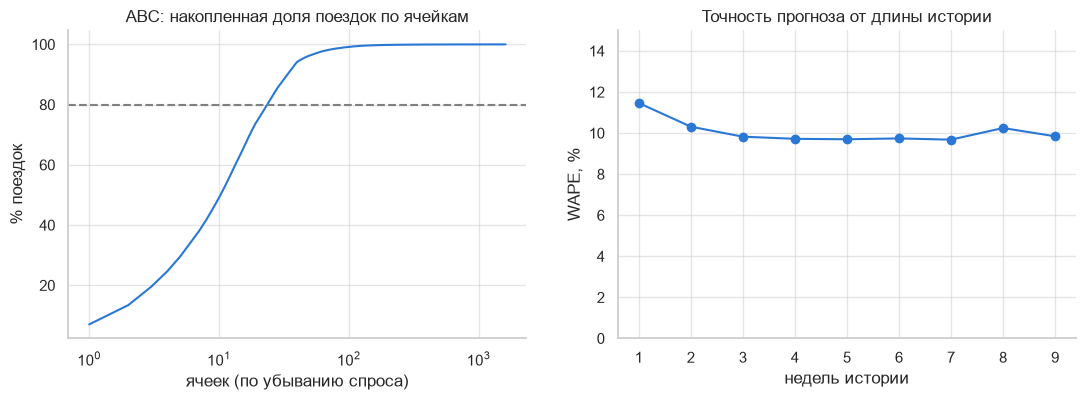

weeks,trips_mln,wape_pct
i64,f64,f64
1,2.71,11.46
2,5.42,10.31
3,8.13,9.82
4,10.84,9.72
5,13.55,9.70
6,16.27,9.74
7,18.98,9.68
8,21.69,10.25
9,24.40,9.84


In [20]:
a_cells = abc.filter(pl.col("abc") == "A").select("cell_lat", "cell_lon")
demand = cells.join(a_cells, on=["cell_lat", "cell_lon"]).filter(pl.col("hour") >= pl.datetime(2016, 1, 1))
test = demand.filter(pl.col("hour") >= pl.datetime(2016, 3, 17))

wape = []
for k in range(1, 10):
    history = pl.concat([demand.with_columns(pl.col("hour") + pl.duration(weeks=w)) for w in range(1, k + 1)])
    forecast = history.group_by("hour", "cell_lat", "cell_lon").agg(pred=pl.col("len").sum() / k)
    joined = test.join(forecast, on=["hour", "cell_lat", "cell_lon"], how="left").fill_null(0)
    wape.append({"weeks": k, "trips_mln": trips_per_day * 7 * k / 1e6,
                 "wape": (joined["len"] - joined["pred"]).abs().sum() / joined["len"].sum()})
wape = pl.DataFrame(wape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(range(1, abc.height + 1), abc["cum_share"] * 100)
ax1.axhline(80, ls="--", c="gray")
ax1.set(title="ABC: накопленная доля поездок по ячейкам", xlabel="ячеек (по убыванию спроса)", ylabel="% поездок", xscale="log")
ax2.plot(wape["weeks"], wape["wape"] * 100, marker="o")
ax2.set(title="Точность прогноза от длины истории", xlabel="недель истории", ylabel="WAPE, %", ylim=(0, 15))
plt.show()
wape.with_columns(wape_pct=pl.col("wape") * 100).drop("wape")

### 5.3. ROI

Ценность прогноза - сокращение холостых машино-часов. Загрузку парка берём из данных: суммарная длительность поездок за сутки против машино-часов на линии. Допущения:
- оператор - парк из 1 000 машин (\~7 % жёлтых такси), 16 ч на линии;
- холостой час стоит 5 долларов: 10 миль пробега X 0.5 долларов за милю (топливо и износ);
- затраты: разработка - 3 человека X 6 месяцев X 15 тыс.; дальше поддержка 1 человек (180 тыс./год) и инфраструктура (\~10 тыс./год: VM по расписанию, Airflow, хранение < 1 доллара).

In [21]:
trip_min = (pl.col("dropoff_datetime") - pl.col("pickup_datetime")).dt.total_minutes()
busy_hours_per_day = trips.filter(trip_min.is_between(1, 360)).select(trip_min.sum() / 60).collect().item() / daily.height
occupancy = busy_hours_per_day / (13_587 * 16)
idle_hours_year = 1_000 * 16 * (1 - occupancy) * 365
print(f"Загрузка парка: {occupancy:.1%}, холостых машино-часов у оператора: {idle_hours_year / 1e6:.1f} млн в год")

dev, run_year = 270_000, 190_000  # $: разработка (6 мес.), поддержка + инфраструктура в год
pl.DataFrame({"idle_reduction_pct": [25, 10, 5]}).with_columns(
    benefit_year=pl.col("idle_reduction_pct") / 100 * idle_hours_year * 5,
).with_columns(
    # 2 года: 6 мес. разработки + 18 мес. работы системы
    roi_2y=(pl.col("benefit_year") * 1.5 - dev - run_year * 1.5) / (dev + run_year * 1.5),
    payback_months=6 + dev / ((pl.col("benefit_year") - run_year) / 12),
)

Загрузка парка: 37.2%, холостых машино-часов у оператора: 3.7 млн в год


idle_reduction_pct,benefit_year,roi_2y,payback_months
i64,f64,f64,f64
25,4 583 667.50,11.39,6.74
10,1 833 467.00,3.96,7.97
5,916 733.50,1.48,10.46


**Итог:** даже если вместо цели в 25 % получится 5 %, проект окупается за \~4.5 месяца после запуска, а ROI за 2 года (1.5) выше порога 0.5 из лекции. Главная статья затрат - люди, а не данные: инфраструктура занимает \~5 % бюджета.

### 5.4. Мониторинг ценности и прогноз на год

| Метрика | Частота | Зачем |
|---|---|---|
| WAPE прогноза по ячейкам A и B | ежедневно | Качество модели, сигнал дрейфа |
| Доля холостых машино-часов (пилот vs контроль) | еженедельно | Прямой бизнес-эффект |
| Доля отброшенных записей по вендору | ежедневно | Veracity, корректность целевой переменной |
| ROI | ежеквартально | Решение о развитии (телеметрия) или сворачивании |

**Через год** ценность данных снизится. Поток поездок жёлтого такси падает на \~15 % в год (конкуренция с Uber и Lyft), и абсолютная экономия падает вместе с ним. Кроме того, TLC переходит с координат на зоны, а конкуренты тоже строят прогнозы. Ожидаемое снижение ценности - \~15-20 % в год, если не добавлять новые источники (телеметрию своего парка, данные FHV).

### Выводы по Value

- **ABC:** 23 ячейки из 1 611 (1.4 %) дают 79 % поездок, 43 ячейки (2.7 %) - 95 %. Остальные 97 % ячеек (класс C) дают 5 % спроса: для них достаточно прогноза на уровне района.
- **Объём против ценности:** точность растёт только до \~3 недель истории (WAPE 11.5 % -> 9.8 %), дальше не меняется, а неделя с метелью в истории её ухудшает. Ценность даёт не объём, а чистые и релевантные данные. Для годовой сезонности всё равно нужен год истории, это проверим после накопления данных.
- **Можно не обрабатывать:** 16 из 19 колонок (тарифы, чаевые, оплата), ячейки класса C детально, сырые поездки старше 2 лет.
- **Затраты оправданы:** ROI за 2 года - 11.4 при цели 25 % и 1.5 при пессимистичных 5 %, окупаемость 7-10.5 месяцев с начала проекта. Проект выгоден даже с большим запасом на ошибку в допущениях.

## Часть 6. Выбор технологий и рекомендации

Критичные V для сценария - **Veracity и Value**. Volume (\~3 ГБ/год) и Velocity (\~5 событий/с, окно 6 часов) не требуют распределённых и потоковых систем. Поэтому стек подбирается по принципу "минимально достаточный сейчас, с понятным путём роста к сценарию C".

### 6.1. Стек и обоснование

| Слой | Выбор | Какую проблему 5V решает | Ограничения | Альтернативы и почему нет |
|---|---|---|---|---|
| Хранение | Yandex Object Storage + Parquet / Apache Iceberg | Volume: x7 сжатие, копейки за хранение. Variety: эволюция схемы (координаты -> зоны). Veracity: откат загрузки по снапшоту | Нужен каталог таблиц (Iceberg REST / Hive Metastore) | HDFS - кластер ради 3 ГБ/год. Delta Lake равноценен, но Iceberg шире поддержан вне Databricks (Spark, Trino, PyIceberg) |
| Обработка | Polars на VM по расписанию -> Spark (Yandex Data Processing) в сценарии C | Volume < 1 ТБ: год данных обрабатывается за секунды на одном узле | Один узел: предел \~1 ТБ | Spark сразу - кластер простаивает 23 часа в сутки. Flink / Kafka Streams - streaming не нужен по Velocity |
| Приём данных | Пакетная загрузка файлов в raw -> Kafka в сценарии C | Velocity: batch раз в сутки, после сбоя данные перечитываются | Нет оперативных данных внутри дня | Kafka сейчас - брокер ради 5 событий/с |
| Качество | Great Expectations в ночном DAG | Veracity: проверка критичных полей, карантин | Проверки нужно поддерживать при смене схемы | Ручные assert - нет отчётов и истории проверок |
| ML | LightGBM + MLflow (эксперименты, реестр моделей) | Value: воспроизводимое обучение, откат модели | MLflow нужно развернуть (или DataSphere) | Feature Store (Feast) - нужен для online-признаков с задержкой в мс, у нас batch: таблица features и есть offline-хранилище признаков |
| Оркестрация | Apache Airflow (Yandex Managed Service for Apache Airflow) | Velocity: дедлайн 06:00, SLA-алерты, ретраи, зависимости шагов | Тяжелее для разработки, чем Prefect | Prefect проще, но managed-версии в Yandex Cloud нет. Cron - нет ретраев, зависимостей и SLA |

### 6.2. Архитектура

```mermaid
flowchart LR
    SRC[Поездки TLC / диспетчерская] --> RAW[(raw: CSV, JSON)]
    WTH[Open-Meteo: погода] --> RAW
    CAL[Праздники, события] --> RAW
    RAW --> GX{Great Expectations}
    GX -- ok --> CLEAN[(clean: trips, weather, calendar - Iceberg)]
    GX -- ошибка --> QUAR[(карантин)]
    CLEAN --> FEAT[Polars: зона X час + признаки]
    FEAT --> FT[(features - Iceberg)]
    FT --> TRAIN[LightGBM]
    TRAIN --> MLF[MLflow: реестр моделей]
    MLF --> PRED[Прогноз на D+1]
    PRED --> PLAN[Планирование смен]
    AF[Airflow: DAG 00:30 - 06:00] -.-> GX & FEAT & TRAIN & PRED
```

**Ресурсы:** VM 8 vCPU / 32 ГБ, работает \~1 час в сутки (обучение, обработка данных - секунды). Object Storage < 10 ГБ за 2 года. Airflow в минимальной конфигурации. В сценарии C добавляются Kafka (3 брокера) и кластер Spark на время ночного пакета.

**Миграция с текущего состояния** (CSV-выгрузки TLC и разовый анализ в ноутбуке): 1) исходные CSV копируются в raw как есть; 2) история конвертируется в Iceberg с единой схемой - код из части 1 переносится в задачу Airflow; 3) ноутбучные агрегаты и проверки из частей 1 и 4 становятся шагами DAG; 4) ноутбук остаётся для исследований.

### 6.3. Риски

| Риск | Минимизация |
|---|---|
| Источник меняет структуру (координаты -> зоны TLC) | Контракт данных и GX-проверка схемы, прогноз сразу строим по зонам |
| Данные TLC публикуются с задержкой, а не ежедневно | Для ежедневной работы использовать данные своей диспетчерской, TLC - для обучения и сверки |
| Аномальные дни (метели, события) ломают прогноз | Погода и календарь событий в признаках, ручная проверка выбросов > 3σ |
| Ночной пакет не успевает к 06:00 | SLA-алерт Airflow в 05:00, фолбэк на вчерашнюю модель |
| Диспетчеры не используют прогноз, эффекта нет | A/B-пилот на части парка, интеграция в планирование смен |
| Падение спроса снижает ценность | Ежеквартальный пересчёт ROI, добавление телеметрии и данных FHV |

### 6.4. Roadmap на 6 месяцев

| Месяц | Этап | Метрика успеха |
|---|---|---|
| 1 | Слои raw/clean в Object Storage, загрузка истории, GX-проверки | 100 % истории загружено, проверки в DAG |
| 2 | Признаки и baseline: сезонное среднее (как в 5.2) | WAPE baseline по ячейкам A и B зафиксирован (\~10 %) |
| 3 | LightGBM с погодой и праздниками, MLflow | WAPE ниже baseline на 15 % |
| 4 | Ночной DAG до 06:00 в эксплуатации, мониторинг | 30 ночей подряд без срыва дедлайна |
| 5 | A/B-пилот на 10 % парка | -10 % холостых машино-часов в пилоте |
| 6 | Раскатка на весь парк, решение по телеметрии (сценарий C) | -25 % холостых машино-часов, пересчитанный ROI |

### Выводы по технологиям

Стек закрывает все 5V без лишнего. **Volume** - Parquet/Iceberg в Object Storage, обработка на одном узле. **Velocity** - ночной batch под Airflow с дедлайном 06:00. **Variety** - явная схема, эволюция схемы Iceberg, перевод координат в зоны. **Veracity** - Great Expectations с карантином и откатом. **Value** - MLflow, A/B-пилот и мониторинг ROI. Распределённые компоненты (Spark, Kafka) не нужны сейчас, но заложены как следующий шаг для сценария C: архитектура и форматы хранения при этом не меняются.

## Заключение

| V | Критичность | Главный факт |
|---|---|---|
| Volume | низкая | 7.4 ГБ CSV -> 1.1 ГБ Parquet, \~3.3 ГБ/год, 1 ТБ только с телеметрией (\~21 мес.) |
| Velocity | низкая | \~4.5 поездки/с, пик x2.1. Окно 6 часов -> batch раз в сутки |
| Variety | средняя | Всё структурировано, сложность - геоданные, внешние источники и смена схемы TLC |
| Veracity | высокая | 1.6 % нулевых координат, систематически у одного вендора. Нужны валидация и карантин |
| Value | высокая | 1.4 % ячеек дают 80 % спроса. ROI окупается даже при 5 % вместо 25 % |

**Рекомендации:** Object Storage + Iceberg, Polars на VM по расписанию, Great Expectations, LightGBM + MLflow, Airflow. Spark и Kafka - только при подключении GPS-телеметрии.

**Бизнес-ценность:** сокращение холостых машино-часов парка из 1 000 машин даёт от \~0.9 долларов до \~4.6 млн долларов экономии в год при затратах \~0.3 млн долларов на разработку и \~0.2 млн долларовв год на поддержку. Затраты на обработку данных оправданы, а ключевой фактор успеха - качество данных и использование прогноза диспетчерами, а не масштаб инфраструктуры.